In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import glob as glob
import csv
import matplotlib.pyplot as plt
import os
from pathlib import Path
import re

N_RULES = 60 + 16
N_TIMECONSTS = 36 + 32
INDEX_AND_LOSS = 2

In [2]:
def read_csv_with_quoted_header(path_pattern):
    # Find first matching file
    files = glob.glob(path_pattern)
    if not files:
        raise FileNotFoundError(f"No files match the pattern: {path_pattern}")
    csv_path = files[0]

    header = []
    with open(csv_path, 'r') as f:
        # Read the first line (header)
        header_line = f.readline().strip()
        curr_word = ''
        in_quote = False
        for c in header_line:
            if in_quote:
                if c == '"':
                    if curr_word != '':
                        header.append(curr_word)
                    curr_word = ''
                    in_quote = False
                else:
                    curr_word += c
            else:
                if c == '"':
                    in_quote = True
                elif c == ' ':
                    if curr_word != '':
                        header.append(curr_word)
                    curr_word = ''
                else:
                    curr_word += c

    # Load data: assume comma-separated numeric values, skipping first line
    data = np.loadtxt(csv_path, delimiter=' ', skiprows=1)

    return header, data

In [3]:
def plot_losses(run_dirs, y_horizontal=200, ylim=(0, 1000), xlim=None):
    for run_dir in run_dirs:
        train_path = f'./sims_out/{run_dir}/train_data.csv'
        header, data = read_csv_with_quoted_header(train_path)
        fig, axs = plt.subplots(1, 1, figsize=(3, 2.5))

        axs.scatter(
            np.arange(data.shape[0]),
            data[:, 1],
            s=2
        )
        axs.plot(np.arange(data.shape[0]), np.full((data.shape[0],), y_horizontal), zorder=-1, c='black')
        print(np.min(data[:, 1]))
        axs.set_ylim(*ylim)
        if xlim is not None:
            axs.set_xlim(*xlim)
        

189.9709014892578
204.94439697265625
194.53395080566406
240.8744354248047
210.4634552001953


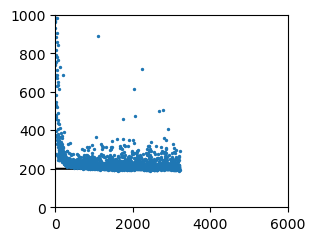

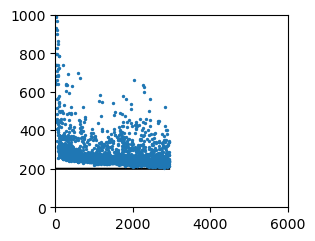

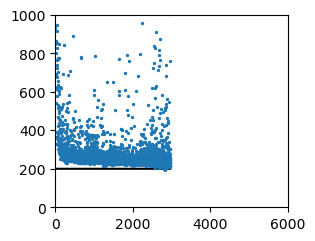

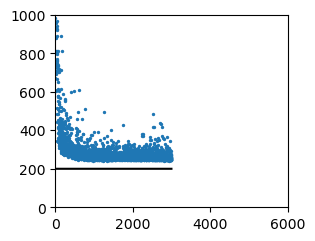

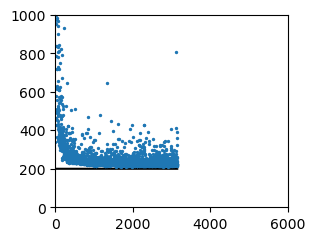

In [5]:
train_paths = [
    'int_preexist_n40_orig_rescale_10_STD_EXPL_0.001_ETA_1.0_L1_PENALTY_5e-07_ACT_PEN_50.0_PRIOR_shift_HdHdS_1.0_HdHrS_1.0_SEED_8100_2025-06-14_17:46:35.975555_run_000061',
    'int_preexist_n40_orig_rescale_10_STD_EXPL_0.001_ETA_1.0_L1_PENALTY_5e-07_ACT_PEN_50.0_PRIOR_shift_HdHdS_1.0_HdHrS_1.0_SEED_8200_2025-06-14_17:46:27.632257_run_000062',
    'int_preexist_n40_orig_rescale_10_STD_EXPL_0.001_ETA_1.0_L1_PENALTY_5e-07_ACT_PEN_50.0_PRIOR_shift_HdHdS_1.0_HdHrS_1.0_SEED_8300_2025-06-14_17:46:35.948565_run_000063',
    'int_preexist_n40_orig_rescale_10_STD_EXPL_0.001_ETA_1.0_L1_PENALTY_5e-07_ACT_PEN_50.0_PRIOR_shift_HdHdS_1.0_HdHrS_1.0_SEED_8400_2025-06-14_17:46:35.948971_run_000064',
    'int_preexist_n40_orig_rescale_10_STD_EXPL_0.001_ETA_1.0_L1_PENALTY_5e-07_ACT_PEN_50.0_PRIOR_shift_HdHdS_1.0_HdHrS_1.0_SEED_8500_2025-06-14_17:46:35.998858_run_000065',
]

plot_losses(train_paths, xlim=(0, 6000), ylim=(0, 1000))

166.70367431640625
215.9458770751953
217.6204071044922
230.4599151611328
226.929931640625


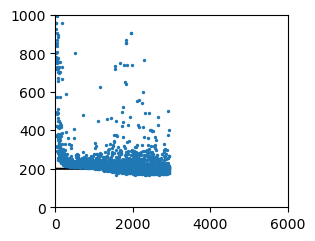

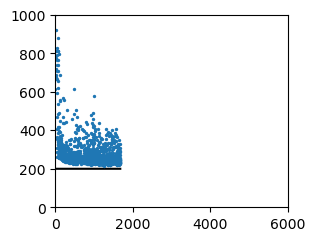

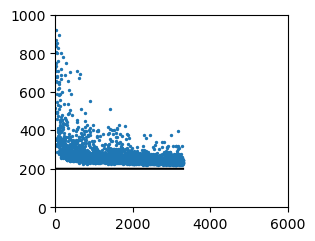

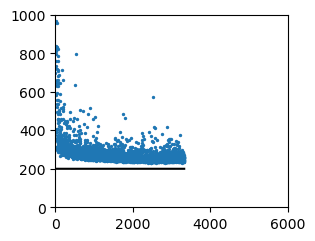

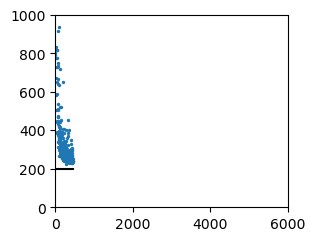

In [5]:
train_paths = [
    'int_preexist_n40_10_STD_EXPL_0.001_ETA_1.0_L1_PENALTY_5e-07_ACT_PEN_50.0_PRIOR_shift_HdHdS_1.0_HdHrS_1.0_SEED_8100_2025-06-08_18:38:08.573723_run_000051',
    'int_preexist_n40_10_STD_EXPL_0.001_ETA_1.0_L1_PENALTY_5e-07_ACT_PEN_50.0_PRIOR_shift_HdHdS_1.0_HdHrS_1.0_SEED_8200_2025-06-09_12:23:54.808644_run_000052',
    'int_preexist_n40_10_STD_EXPL_0.001_ETA_1.0_L1_PENALTY_5e-07_ACT_PEN_50.0_PRIOR_shift_HdHdS_1.0_HdHrS_1.0_SEED_8300_2025-06-08_18:38:43.383908_run_000053',
    'int_preexist_n40_10_STD_EXPL_0.001_ETA_1.0_L1_PENALTY_5e-07_ACT_PEN_50.0_PRIOR_shift_HdHdS_1.0_HdHrS_1.0_SEED_8400_2025-06-08_18:40:00.647840_run_000054',
    'int_preexist_n40_10_STD_EXPL_0.001_ETA_1.0_L1_PENALTY_5e-07_ACT_PEN_50.0_PRIOR_shift_HdHdS_1.0_HdHrS_1.0_SEED_8500_2025-06-09_12:23:54.808646_run_000055',
]

plot_losses(train_paths, xlim=(0, 6000), ylim=(0, 1000))

In [6]:
train_paths = [
    'int_preexist_n40_10_STD_EXPL_0.001_ETA_1.0_L1_PENALTY_5e-07_ACT_PEN_50.0_PRIOR_shift_HdHdS_1.0_HdHrS_1.0_SEED_8100_2025-06-06_21:17:31.884665_run_000041',
    'int_preexist_n40_10_STD_EXPL_0.001_ETA_1.0_L1_PENALTY_5e-07_ACT_PEN_50.0_PRIOR_shift_HdHdS_1.0_HdHrS_1.0_SEED_8200_2025-06-06_21:17:36.923817_run_000042',
    'int_preexist_n40_10_STD_EXPL_0.001_ETA_1.0_L1_PENALTY_5e-07_ACT_PEN_50.0_PRIOR_shift_HdHdS_1.0_HdHrS_1.0_SEED_8300_2025-06-06_21:21:11.437134_run_000043',
    'int_preexist_n40_10_STD_EXPL_0.001_ETA_1.0_L1_PENALTY_5e-07_ACT_PEN_50.0_PRIOR_shift_HdHdS_1.0_HdHrS_1.0_SEED_8400_2025-06-06_21:21:11.437133_run_000044',
    'int_preexist_n40_10_STD_EXPL_0.001_ETA_1.0_L1_PENALTY_5e-07_ACT_PEN_50.0_PRIOR_shift_HdHdS_1.0_HdHrS_1.0_SEED_8500_2025-06-06_21:18:39.028091_run_000045',
]

plot_losses(train_paths, xlim=(0, 6000))

FileNotFoundError: No files match the pattern: ./sims_out/int_preexist_n40_10_STD_EXPL_0.001_ETA_1.0_L1_PENALTY_5e-07_ACT_PEN_50.0_PRIOR_shift_HdHdS_1.0_HdHrS_1.0_SEED_8100_2025-06-06_21:17:31.884665_run_000041/train_data.csv

317.1287536621094
180.48304748535156
248.288818359375
179.94387817382812
276.0492248535156


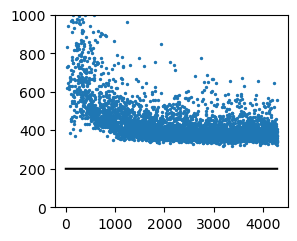

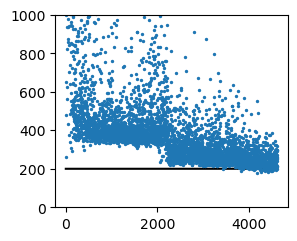

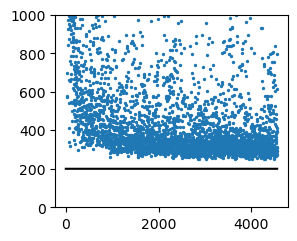

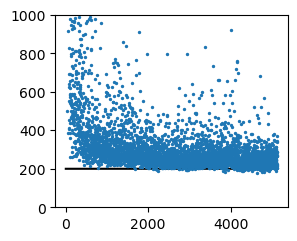

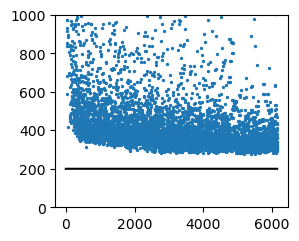

In [8]:
train_paths = [
    'int_preexist_n40_10_STD_EXPL_0.001_ETA_1.0_L1_PENALTY_5e-07_ACT_PEN_50.0_PRIOR_shift_HdHdS_1.0_HdHrS_1.0_SEED_8100_2025-05-30_10:25:52.792036_run_000021',
    'int_preexist_n40_10_STD_EXPL_0.001_ETA_1.0_L1_PENALTY_5e-07_ACT_PEN_50.0_PRIOR_shift_HdHdS_1.0_HdHrS_1.0_SEED_8200_2025-05-30_10:25:52.792032_run_000022',
    'int_preexist_n40_10_STD_EXPL_0.001_ETA_1.0_L1_PENALTY_5e-07_ACT_PEN_50.0_PRIOR_shift_HdHdS_1.0_HdHrS_1.0_SEED_8300_2025-05-29_21:11:53.022091_run_000023',
    'int_preexist_n40_10_STD_EXPL_0.001_ETA_1.0_L1_PENALTY_5e-07_ACT_PEN_50.0_PRIOR_shift_HdHdS_1.0_HdHrS_1.0_SEED_8400_2025-05-29_21:11:53.022088_run_000024',
    'int_preexist_n40_10_STD_EXPL_0.001_ETA_1.0_L1_PENALTY_5e-07_ACT_PEN_50.0_PRIOR_shift_HdHdS_1.0_HdHrS_1.0_SEED_8500_2025-05-29_21:11:52.918555_run_000025',
]

plot_losses(train_paths)

406.2947998046875
363.4463195800781
399.9322204589844
389.68548583984375
429.7765197753906


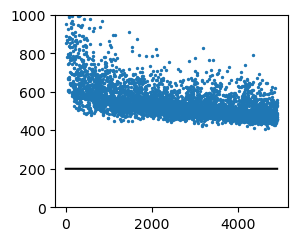

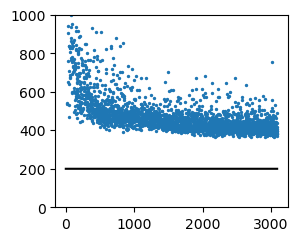

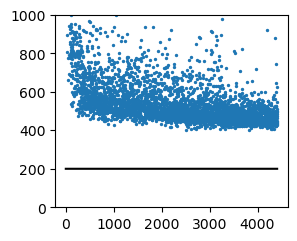

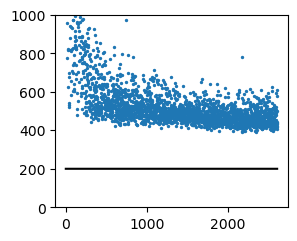

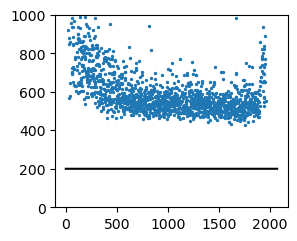

In [7]:
train_paths = [
    'int_preexist_n40_10_STD_EXPL_0.001_ETA_1.0_L1_PENALTY_5e-07_ACT_PEN_50.0_PRIOR_shift_HdHdS_0.5_HdHrS_0.5_SEED_8100_2025-05-29_21:11:52.918572_run_000031',
    'int_preexist_n40_10_STD_EXPL_0.001_ETA_1.0_L1_PENALTY_5e-07_ACT_PEN_50.0_PRIOR_shift_HdHdS_0.5_HdHrS_0.5_SEED_8200_2025-05-29_21:11:52.918556_run_000032',
    'int_preexist_n40_10_STD_EXPL_0.001_ETA_1.0_L1_PENALTY_5e-07_ACT_PEN_50.0_PRIOR_shift_HdHdS_0.5_HdHrS_0.5_SEED_8300_2025-05-30_10:26:36.477610_run_000033',
    'int_preexist_n40_10_STD_EXPL_0.001_ETA_1.0_L1_PENALTY_5e-07_ACT_PEN_50.0_PRIOR_shift_HdHdS_0.5_HdHrS_0.5_SEED_8400_2025-05-30_10:28:04.286716_run_000034',
    'int_preexist_n40_10_STD_EXPL_0.001_ETA_1.0_L1_PENALTY_5e-07_ACT_PEN_50.0_PRIOR_shift_HdHdS_0.5_HdHrS_0.5_SEED_8500_2025-05-30_10:28:04.286727_run_000035',
]

plot_losses(train_paths)

1774.2177696234637
1716.3034588410453
2284.1030285863326
1863.326872830773


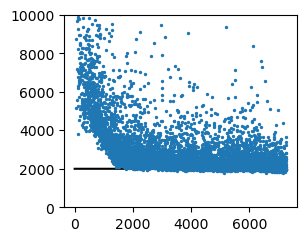

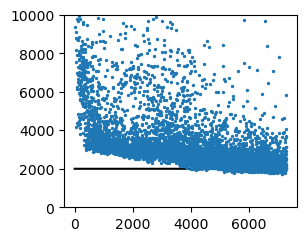

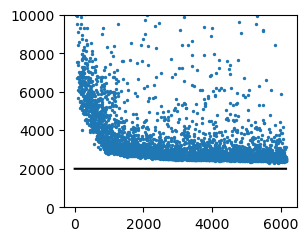

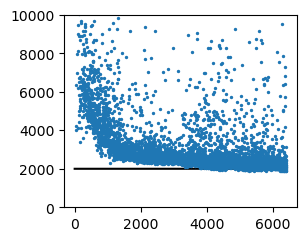

In [5]:
train_paths = [
    'int_preexist_inputs_rand10_STD_EXPL_0.001_FIXED_True_L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_1.0_FRACI_0.0_SEED_8051_2025-03-31_14:10:57.049743',
    'int_preexist_inputs_rand10_STD_EXPL_0.001_FIXED_True_L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_1.0_FRACI_0.0_SEED_8052_2025-03-31_22:17:51.916099',
    'int_preexist_inputs_rand10_STD_EXPL_0.001_FIXED_True_L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_1.0_FRACI_0.0_SEED_8053_2025-03-31_22:34:23.654335',
    'int_preexist_inputs_rand10_STD_EXPL_0.001_FIXED_True_L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_1.0_FRACI_0.0_SEED_8054_2025-03-31_22:35:39.288195',
]

plot_losses(train_paths, ylim=(0, 10000), y_horizontal=2000)

2057.620376073351
1575.7003056703854
1883.6249879866718
1718.8797348284982


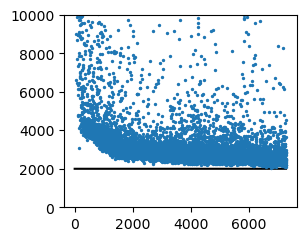

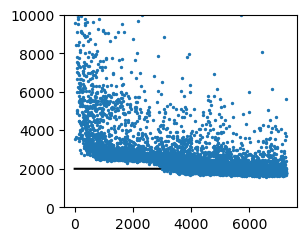

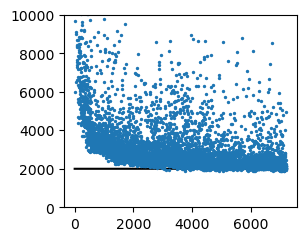

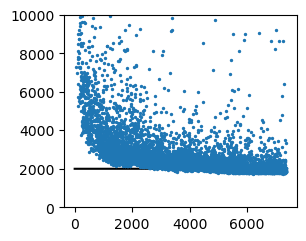

In [6]:
train_paths = [
    'int_preexist_inputs_asym_rand10_STD_EXPL_0.001_FIXED_True_L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_1.0_FRACI_0.0_SEED_8051_2025-04-03_18:56:20.335393',
    'int_preexist_inputs_asym_rand10_STD_EXPL_0.001_FIXED_True_L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_1.0_FRACI_0.0_SEED_8052_2025-04-03_18:56:20.335369',
    'int_preexist_inputs_asym_rand10_STD_EXPL_0.001_FIXED_True_L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_1.0_FRACI_0.0_SEED_8053_2025-04-03_22:10:24.675697',
    'int_preexist_inputs_asym_rand10_STD_EXPL_0.001_FIXED_True_L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_1.0_FRACI_0.0_SEED_8054_2025-04-04_06:18:06.402567',
]

plot_losses(train_paths, ylim=(0, 10000), y_horizontal=2000)